# 04 — Modeling

Goal: compare all three feature sets (full / correlation-filtered / Mann-Whitney), four imbalance strategies, and five model families using a staged approach — coarse-screen all 60 combos with 5-fold CV, then tune the top 5 with Optuna + Successive Halving (ASHA) pruning, and finally select the winner using the held-out validation set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import joblib
import optuna
from optuna.pruners import SuccessiveHalvingPruner
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

REPORT_DIR = '../results/04_modeling'
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)

## 1. Load Data

Three feature-set variants are loaded (train + val only — test is reserved for `05_evaluation.ipynb`). All three share the same row membership (same `random_state` in `03_preprocessing.ipynb`), so PR-AUC is directly comparable across them.

In [2]:
datasets = {}
for name in ['full', 'selected', 'mannwhitney']:
    train = pd.read_csv(f'../data/processed/train_{name}.csv')
    val   = pd.read_csv(f'../data/processed/val_{name}.csv')
    X_train = train.drop(columns=['Class'])
    y_train = train['Class']
    X_val   = val.drop(columns=['Class'])
    y_val   = val['Class']
    datasets[name] = (X_train, y_train, X_val, y_val)
    print(f'[{name}] train: {X_train.shape}, val: {X_val.shape}')

[full] train: (170883, 30), val: (56962, 30)


[selected] train: (170883, 28), val: (56962, 28)


[mannwhitney] train: (170883, 24), val: (56962, 24)


## 2. Define Models and Pipeline Builder

**Imbalance strategies**: `smote`, `random_over`, `random_under`, `class_weight`.
**Models**: Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost (5 total).

Resamplers are wrapped inside an `imblearn` `Pipeline` so they only touch the training fold during cross-validation — never the validation fold — avoiding label-leakage.

In [3]:
IMBALANCE_STRATEGIES = ['smote', 'random_over', 'random_under', 'class_weight']
MODEL_NAMES = ['logistic_regression', 'random_forest', 'xgboost', 'lgbm', 'catboost']


def make_sampler(strategy):
    if strategy == 'smote':
        return SMOTE(random_state=42)
    if strategy == 'random_over':
        return RandomOverSampler(random_state=42)
    if strategy == 'random_under':
        return RandomUnderSampler(random_state=42)
    if strategy == 'class_weight':
        return None
    raise ValueError(strategy)


def make_model(model_name, strategy, y_train, **hyperparams):
    if model_name == 'logistic_regression':
        kwargs = dict(max_iter=1000, random_state=42)
        if strategy == 'class_weight':
            kwargs['class_weight'] = 'balanced'
        kwargs.update(hyperparams)
        return LogisticRegression(**kwargs)

    if model_name == 'random_forest':
        kwargs = dict(random_state=42, n_jobs=-1)
        if strategy == 'class_weight':
            kwargs['class_weight'] = 'balanced'
        kwargs.update(hyperparams)
        return RandomForestClassifier(**kwargs)

    if model_name == 'xgboost':
        kwargs = dict(random_state=42, eval_metric='aucpr', verbosity=0)
        if strategy == 'class_weight':
            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
            kwargs['scale_pos_weight'] = neg / pos
        kwargs.update(hyperparams)
        return XGBClassifier(**kwargs)

    if model_name == 'lgbm':
        kwargs = dict(random_state=42, verbose=-1, n_jobs=-1)
        if strategy == 'class_weight':
            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
            kwargs['scale_pos_weight'] = neg / pos
        kwargs.update(hyperparams)
        return LGBMClassifier(**kwargs)

    if model_name == 'catboost':
        kwargs = dict(random_seed=42, verbose=0)
        if strategy == 'class_weight':
            # auto_class_weights='Balanced' is sklearn-clonable; class_weights=[list]
            # breaks sklearn's clone() because CatBoost normalises the list internally.
            kwargs['auto_class_weights'] = 'Balanced'
        kwargs.update(hyperparams)
        return CatBoostClassifier(**kwargs)

    raise ValueError(model_name)


def make_pipeline(model_name, strategy, y_train, **hyperparams):
    sampler = make_sampler(strategy)
    model = make_model(model_name, strategy, y_train, **hyperparams)
    steps = []
    if sampler is not None:
        steps.append(('sampler', sampler))
    steps.append(('clf', model))
    return ImbPipeline(steps)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 3. Stage 1 — Coarse Screening (Default Hyperparameters)

All `3 feature sets × 4 imbalance strategies × 5 models = 60` combinations, scored by 5-fold cross-validated PR-AUC with default hyperparameters. This identifies promising candidates cheaply before spending budget on Bayesian tuning.

In [4]:
screening_rows = []
for feature_set in ['full', 'selected', 'mannwhitney']:
    X_train, y_train, _, _ = datasets[feature_set]
    for strategy in IMBALANCE_STRATEGIES:
        for model_name in MODEL_NAMES:
            pipe = make_pipeline(model_name, strategy, y_train)
            scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=1)
            screening_rows.append({
                'feature_set': feature_set,
                'imbalance_strategy': strategy,
                'model': model_name,
                'mean_prauc': scores.mean(),
                'std_prauc': scores.std(),
            })
            print(f'[{feature_set}/{strategy}/{model_name}] PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

screening_results = pd.DataFrame(screening_rows).sort_values('mean_prauc', ascending=False).reset_index(drop=True)
screening_results.to_csv(f'{REPORT_DIR}/coarse_screening_results.csv', index=False)
print(f'\nTotal combos evaluated: {len(screening_results)}')
screening_results.head(10)

[full/smote/logistic_regression] PR-AUC = 0.7802 ± 0.0672


[full/smote/random_forest] PR-AUC = 0.8446 ± 0.0807


[full/smote/xgboost] PR-AUC = 0.8487 ± 0.0778


[full/smote/lgbm] PR-AUC = 0.7520 ± 0.0797


[full/smote/catboost] PR-AUC = 0.8392 ± 0.0844


...

[mannwhitney/class_weight/random_forest] PR-AUC = 0.8478 ± 0.0860


[mannwhitney/class_weight/xgboost] PR-AUC = 0.8530 ± 0.0836


[mannwhitney/class_weight/lgbm] PR-AUC = 0.0165 ± 0.0195


[mannwhitney/class_weight/catboost] PR-AUC = 0.8374 ± 0.0906

Total combos evaluated: 60


,feature_set,imbalance_strategy,model,mean_prauc,std_prauc
0,selected,random_over,xgboost,0.859094,0.080533
1,selected,class_weight,xgboost,0.857435,0.081805
2,full,class_weight,xgboost,0.855538,0.082431
3,full,random_over,xgboost,0.855272,0.080114
4,mannwhitney,class_weight,xgboost,0.852952,0.083639
5,mannwhitney,random_over,xgboost,0.851696,0.084581
6,full,class_weight,random_forest,0.851113,0.079138
7,mannwhitney,random_over,random_forest,0.850531,0.086235
8,selected,random_over,random_forest,0.850395,0.079803
9,selected,smote,xgboost,0.850321,0.081448


## 4. Stage 2 — Bayesian HPO with Successive Halving (ASHA) Pruning

Full tuning only on the top 5 candidates from Stage 1. The Optuna objective reports each fold's running-mean PR-AUC as an intermediate value after each fold. Optuna's `SuccessiveHalvingPruner` (≈ ASHA) kills clearly-underperforming trials early, freeing budget for better candidates — more efficient than plain Bayesian optimization at the same trial count.

> To speed up local runs, reduce `N_TRIALS`. The pruner typically saves ~30–50% of trial compute by early-stopping bad configurations after the first 1–2 folds.

In [5]:
TOP_N = 5
N_TRIALS = 50
top_combos = screening_results.head(TOP_N).to_dict('records')


def suggest_hyperparams(trial, model_name):
    if model_name == 'logistic_regression':
        return {
            'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
            'solver': 'liblinear',
        }
    if model_name == 'random_forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'xgboost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        }
    if model_name == 'lgbm':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        }
    if model_name == 'catboost':
        return {
            'iterations': trial.suggest_int('iterations', 50, 500),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        }
    raise ValueError(model_name)


def build_objective(strategy, model_name, X_train, y_train):
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def objective(trial):
        params = suggest_hyperparams(trial, model_name)
        scores = []
        for step, (tr_idx, val_idx) in enumerate(cv_inner.split(X_train, y_train)):
            fold_y_tr = y_train.iloc[tr_idx]
            pipe = make_pipeline(model_name, strategy, fold_y_tr, **params)
            pipe.fit(X_train.iloc[tr_idx], fold_y_tr)
            prob = pipe.predict_proba(X_train.iloc[val_idx])[:, 1]
            scores.append(average_precision_score(y_train.iloc[val_idx], prob))
            trial.report(float(np.mean(scores)), step)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return float(np.mean(scores))
    return objective


tuning_rows = []
tuned_params = {}

for combo in top_combos:
    feature_set = combo['feature_set']
    strategy = combo['imbalance_strategy']
    model_name = combo['model']
    X_train, y_train, _, _ = datasets[feature_set]

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=SuccessiveHalvingPruner(),
    )
    study.optimize(build_objective(strategy, model_name, X_train, y_train), n_trials=N_TRIALS)

    tuning_rows.append({
        'feature_set': feature_set,
        'imbalance_strategy': strategy,
        'model': model_name,
        'best_cv_prauc': study.best_value,
        'best_params': json.dumps(study.best_params),
    })
    tuned_params[(feature_set, strategy, model_name)] = study.best_params

    print(f'[{feature_set}/{strategy}/{model_name}] best CV PR-AUC = {study.best_value:.4f}')
    print(f'  params = {study.best_params}')

tuning_results = pd.DataFrame(tuning_rows).sort_values('best_cv_prauc', ascending=False).reset_index(drop=True)
tuning_results.to_csv(f'{REPORT_DIR}/bayesian_tuning_results.csv', index=False)
tuning_results

[selected/random_over/xgboost] best CV PR-AUC = 0.8635
  params = {'n_estimators': 142, 'max_depth': 10, 'learning_rate': 0.16512959604161906, 'subsample': 0.6653139182680297, 'colsample_bytree': 0.6511397506377327}


[selected/class_weight/xgboost] best CV PR-AUC = 0.8622
  params = {'n_estimators': 256, 'max_depth': 10, 'learning_rate': 0.09474347727058283, 'subsample': 0.9052682321579768, 'colsample_bytree': 0.9625632338704709}


[full/class_weight/xgboost] best CV PR-AUC = 0.8642
  params = {'n_estimators': 122, 'max_depth': 9, 'learning_rate': 0.1062272193666865, 'subsample': 0.8947385331597324, 'colsample_bytree': 0.6738167152482913}


[full/random_over/xgboost] best CV PR-AUC = 0.8667
  params = {'n_estimators': 229, 'max_depth': 9, 'learning_rate': 0.1399546811388897, 'subsample': 0.6374264744976315, 'colsample_bytree': 0.9173029265728927}


[mannwhitney/class_weight/xgboost] best CV PR-AUC = 0.8594
  params = {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}


,feature_set,imbalance_strategy,model,best_cv_prauc,best_params
0,full,random_over,xgboost,0.866672,"{""n_estimators"": 229, ""max_depth"": 9, ""learnin..."
1,full,class_weight,xgboost,0.864178,"{""n_estimators"": 122, ""max_depth"": 9, ""learnin..."
2,selected,random_over,xgboost,0.863530,"{""n_estimators"": 142, ""max_depth"": 10, ""learni..."
3,selected,class_weight,xgboost,0.862158,"{""n_estimators"": 256, ""max_depth"": 10, ""learni..."
4,mannwhitney,class_weight,xgboost,0.859408,"{""n_estimators"": 144, ""max_depth"": 10, ""learni..."


## 5. Final Model Selection (Validation Set)

Each tuned model is refitted on its full train split and evaluated on the **held-out validation set**. The winner is chosen by validation PR-AUC — this is the first time the validation set is used, so the selection is unbiased with respect to the tuning objective.

In [6]:
val_results = []
for combo_row in tuning_results.to_dict('records'):
    fs = combo_row['feature_set']
    strat = combo_row['imbalance_strategy']
    mn = combo_row['model']
    params = json.loads(combo_row['best_params'])

    X_tr, y_tr, X_vl, y_vl = datasets[fs]
    pipe = make_pipeline(mn, strat, y_tr, **params)
    pipe.fit(X_tr, y_tr)
    val_prauc = average_precision_score(y_vl, pipe.predict_proba(X_vl)[:, 1])
    val_results.append({
        'feature_set': fs,
        'imbalance_strategy': strat,
        'model': mn,
        'cv_prauc': combo_row['best_cv_prauc'],
        'val_prauc': val_prauc,
    })
    print(f'[{fs}/{strat}/{mn}]  CV PR-AUC = {combo_row["best_cv_prauc"]:.4f}  |  Val PR-AUC = {val_prauc:.4f}')

val_df = pd.DataFrame(val_results).sort_values('val_prauc', ascending=False).reset_index(drop=True)
print('\n--- Final ranking by validation PR-AUC ---')
print(val_df.to_string(index=False))

best_row = val_df.iloc[0]
best_feature_set  = best_row['feature_set']
best_strategy     = best_row['imbalance_strategy']
best_model_name   = best_row['model']
best_params       = tuned_params[(best_feature_set, best_strategy, best_model_name)]

print(f'\nSelected: {best_feature_set} / {best_strategy} / {best_model_name}')
print(f'Val PR-AUC: {best_row["val_prauc"]:.4f}')

[full/random_over/xgboost]  CV PR-AUC = 0.8667  |  Val PR-AUC = 0.8185


[full/class_weight/xgboost]  CV PR-AUC = 0.8642  |  Val PR-AUC = 0.8244


[selected/random_over/xgboost]  CV PR-AUC = 0.8635  |  Val PR-AUC = 0.8251


[selected/class_weight/xgboost]  CV PR-AUC = 0.8622  |  Val PR-AUC = 0.8242


[mannwhitney/class_weight/xgboost]  CV PR-AUC = 0.8594  |  Val PR-AUC = 0.8239

--- Final ranking by validation PR-AUC ---
feature_set imbalance_strategy   model  cv_prauc  val_prauc
   selected        random_over xgboost  0.863530   0.825114
       full       class_weight xgboost  0.864178   0.824434
   selected       class_weight xgboost  0.862158   0.824204
mannwhitney       class_weight xgboost  0.859408   0.823859
       full        random_over xgboost  0.866672   0.818512

Selected: selected / random_over / xgboost
Val PR-AUC: 0.8251


In [7]:
X_train_best, y_train_best, X_val_best, y_val_best = datasets[best_feature_set]

best_pipeline = make_pipeline(best_model_name, best_strategy, y_train_best, **best_params)
best_pipeline.fit(X_train_best, y_train_best)

val_prauc_final = average_precision_score(y_val_best, best_pipeline.predict_proba(X_val_best)[:, 1])
print(f'Best model val PR-AUC (fitted on full train): {val_prauc_final:.4f}')

joblib.dump(best_pipeline, '../models/best_model.pkl')

metadata = {
    'feature_set':        best_feature_set,
    'imbalance_strategy': best_strategy,
    'model':              best_model_name,
    'hyperparameters':    best_params,
    'features':           list(X_train_best.columns),
    'val_prauc':          val_prauc_final,
}
with open('../models/best_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/best_model.pkl')
print('Saved: models/best_model_metadata.json')
print(f'Features used ({len(metadata["features"])}): {metadata["features"]}')

Best model val PR-AUC (fitted on full train): 0.8251
Saved: models/best_model.pkl
Saved: models/best_model_metadata.json
Features used (28): ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V21', 'V19', 'V20', 'V8', 'V27', 'V28', 'V24', 'V13', 'V26', 'V15', 'V25', 'V23', 'V22']


## 6. Feature Count vs. Performance

Using the winning model/strategy/hyperparameters, rank features by importance and retrain on the top `K` for increasing `K` to find the smallest feature count that preserves performance.

K=5: PR-AUC = 0.8257 ± 0.0908


K=10: PR-AUC = 0.8404 ± 0.0857


K=15: PR-AUC = 0.8503 ± 0.0833


K=20: PR-AUC = 0.8484 ± 0.0844


K=25: PR-AUC = 0.8576 ± 0.0791


K=28: PR-AUC = 0.8587 ± 0.0789

Minimal recommended feature count: K=15 (PR-AUC=0.8503, within 1% of max 0.8587)


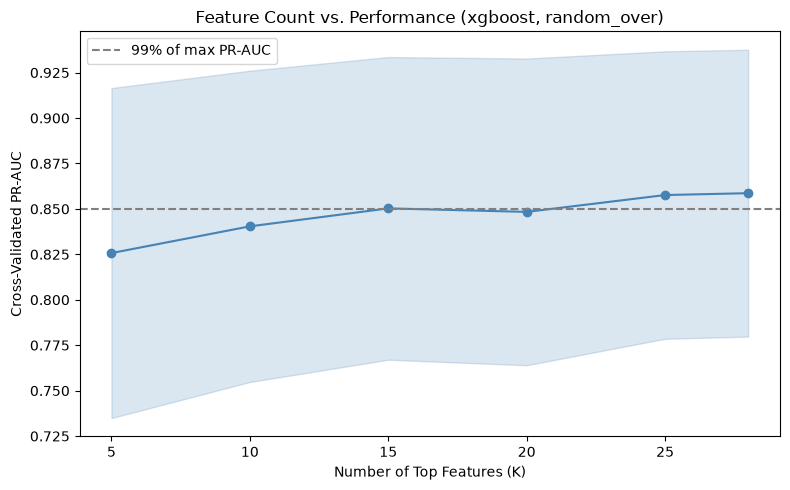

In [8]:
fitted_clf = best_pipeline.named_steps['clf']

if hasattr(fitted_clf, 'feature_importances_'):
    importances = pd.Series(fitted_clf.feature_importances_, index=X_train_best.columns)
elif hasattr(fitted_clf, 'coef_'):
    importances = pd.Series(np.abs(fitted_clf.coef_[0]), index=X_train_best.columns)
else:
    raise ValueError('Model has neither feature_importances_ nor coef_')

ranked_features = importances.sort_values(ascending=False).index.tolist()
max_k = len(ranked_features)

k_values = [k for k in [5, 10, 15, 20, 25, 30] if k <= max_k]
if max_k not in k_values:
    k_values.append(max_k)

curve_rows = []
for k in k_values:
    top_k_features = ranked_features[:k]
    pipe = make_pipeline(best_model_name, best_strategy, y_train_best, **best_params)
    scores = cross_val_score(pipe, X_train_best[top_k_features], y_train_best,
                             cv=cv, scoring='average_precision', n_jobs=1)
    curve_rows.append({'k': k, 'mean_prauc': scores.mean(), 'std_prauc': scores.std()})
    print(f'K={k}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}')

curve_df = pd.DataFrame(curve_rows)
curve_df.to_csv(f'{REPORT_DIR}/feature_count_vs_prauc.csv', index=False)

max_prauc = curve_df['mean_prauc'].max()
minimal_k_row = curve_df[curve_df['mean_prauc'] >= max_prauc * 0.99].iloc[0]
print(f"\nMinimal recommended feature count: K={int(minimal_k_row['k'])} "
      f"(PR-AUC={minimal_k_row['mean_prauc']:.4f}, within 1% of max {max_prauc:.4f})")

plt.figure(figsize=(8, 5))
plt.plot(curve_df['k'], curve_df['mean_prauc'], marker='o', color='steelblue')
plt.fill_between(curve_df['k'],
                 curve_df['mean_prauc'] - curve_df['std_prauc'],
                 curve_df['mean_prauc'] + curve_df['std_prauc'],
                 alpha=0.2, color='steelblue')
plt.axhline(max_prauc * 0.99, linestyle='--', color='gray', label='99% of max PR-AUC')
plt.xlabel('Number of Top Features (K)')
plt.ylabel('Cross-Validated PR-AUC')
plt.title(f'Feature Count vs. Performance ({best_model_name}, {best_strategy})')
plt.legend()
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/feature_count_vs_prauc.png', dpi=150)
plt.show()